In [15]:
!pip install tensorflow opencv-python

     |████████████████████████████████| 48.3 MB 22.8 MB/s eta 0:00:01
You should consider upgrading via the '/Users/leathermajesty/notebook/.venv/bin/python3 -m pip install --upgrade pip' command.


In [8]:
print(tf.__version__)
print(keras.__version__)

2.20.0
3.10.0


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_digit_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

model = build_digit_cnn()

# Load the trained weights
model.load_weights("../saved_model/digit_cnn.keras")

# Compile for further training
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Same preprocessing used during training
X_test = X_test.astype("float32") / 255.0
X_test = X_test.reshape(-1, 28, 28, 1)

# Predict first 10 images
predictions = model.predict(X_test[:10])

predicted_digits = np.argmax(predictions, axis=1)

print("Actual:   ", y_test[:10])
print("Predicted:", predicted_digits)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Actual:    [7 2 1 0 4 1 4 9 5 9]
Predicted: [7 2 1 0 4 1 4 9 5 9]


In [11]:
#Then check the complete test accuracy:

loss, accuracy = model.evaluate(
    X_test,
    keras.utils.to_categorical(y_test, 10),
    verbose=0
)


print(f"Test accuracy: {accuracy * 100:.2f}%")

Test accuracy: 99.23%


In [12]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_digit(image_path):
    # Load image
    image = Image.open(image_path).convert("L")

    # Resize to model input size
    image = image.resize((28, 28))

    # Convert to NumPy array
    image_array = np.array(image).astype("float32")

    # Normalize
    image_array = image_array / 255.0

    # Add channel dimension and batch dimension
    image_array = image_array.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(image_array, verbose=0)

    digit = np.argmax(prediction[0])
    confidence = prediction[0][digit] * 100

    # Show image
    plt.imshow(image_array[0].reshape(28, 28), cmap="gray")
    plt.title(f"Prediction: {digit} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return digit, confidence

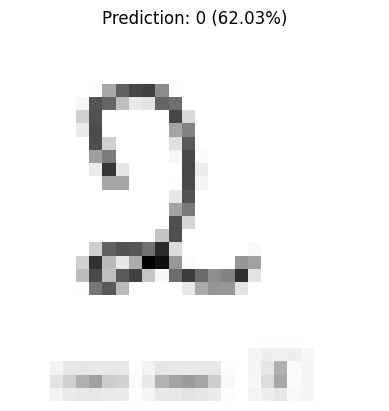

Predicted digit: 0
Confidence: 62.03%


In [14]:
digit, confidence = predict_digit("../test_images/2.png")

print("Predicted digit:", digit)
print("Confidence:", f"{confidence:.2f}%")

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_digit(image_path, debug=True):

    # -----------------------------
    # 1. Read image
    # -----------------------------
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError("Could not read image")

    # -----------------------------
    # 2. Threshold
    # -----------------------------
    _, binary = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # -----------------------------
    # 3. Find connected components
    # -----------------------------
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary,
        connectivity=8
    )

    components = []

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]

        # Remove tiny noise
        if area > 50:
            components.append((i, x, y, w, h, area))

    if not components:
        raise ValueError("No digit detected")

    # Largest component = digit
    label, x, y, w, h, area = max(
        components,
        key=lambda c: c[5]
    )

    # -----------------------------
    # 4. Extract digit
    # -----------------------------
    digit = np.zeros_like(binary)
    digit[labels == label] = 255

    digit = digit[y:y+h, x:x+w]

    # -----------------------------
    # 5. Add padding
    # -----------------------------
    padding = 10

    digit = cv2.copyMakeBorder(
        digit,
        padding,
        padding,
        padding,
        padding,
        cv2.BORDER_CONSTANT,
        value=0
    )

    # -----------------------------
    # 6. Resize to ~20x20
    # -----------------------------
    target_size = 20

    h, w = digit.shape

    scale = target_size / max(h, w)

    new_h = max(1, int(h * scale))
    new_w = max(1, int(w * scale))

    digit = cv2.resize(
        digit,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # -----------------------------
    # 7. Increase stroke thickness
    # -----------------------------
    kernel = np.ones((2, 2), np.uint8)

    digit_thick = cv2.dilate(
        digit,
        kernel,
        iterations=1
    )

    # -----------------------------
    # 8. Create 28x28 canvas
    # -----------------------------
    canvas = np.zeros((28, 28), dtype=np.uint8)

    # Put digit approximately in center
    y_start = (28 - new_h) // 2
    x_start = (28 - new_w) // 2

    canvas[
        y_start:y_start + new_h,
        x_start:x_start + new_w
    ] = digit_thick

    # -----------------------------
    # 9. Center using center of mass
    # -----------------------------
    moments = cv2.moments(canvas)

    if moments["m00"] != 0:

        cx = moments["m10"] / moments["m00"]
        cy = moments["m01"] / moments["m00"]

        # Desired center
        target_cx = 13.5
        target_cy = 13.5

        shift_x = int(round(target_cx - cx))
        shift_y = int(round(target_cy - cy))

        M = np.float32([
            [1, 0, shift_x],
            [0, 1, shift_y]
        ])

        canvas = cv2.warpAffine(
            canvas,
            M,
            (28, 28),
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

    # -----------------------------
    # 10. Normalize
    # -----------------------------
    normalized = canvas.astype("float32") / 255.0

    # CNN input shape
    model_input = normalized.reshape(1, 28, 28, 1)

    # -----------------------------
    # Debug visualization
    # -----------------------------
    if debug:

        fig, axes = plt.subplots(1, 5, figsize=(15, 3))

        axes[0].imshow(img, cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(binary, cmap="gray")
        axes[1].set_title("Threshold")
        axes[1].axis("off")

        axes[2].imshow(digit, cmap="gray")
        axes[2].set_title("Resized")
        axes[2].axis("off")

        axes[3].imshow(digit_thick, cmap="gray")
        axes[3].set_title("Thicker Stroke")
        axes[3].axis("off")

        axes[4].imshow(canvas, cmap="gray")
        axes[4].set_title("Final 28×28")
        axes[4].axis("off")

        plt.tight_layout()
        plt.show()

    return model_input

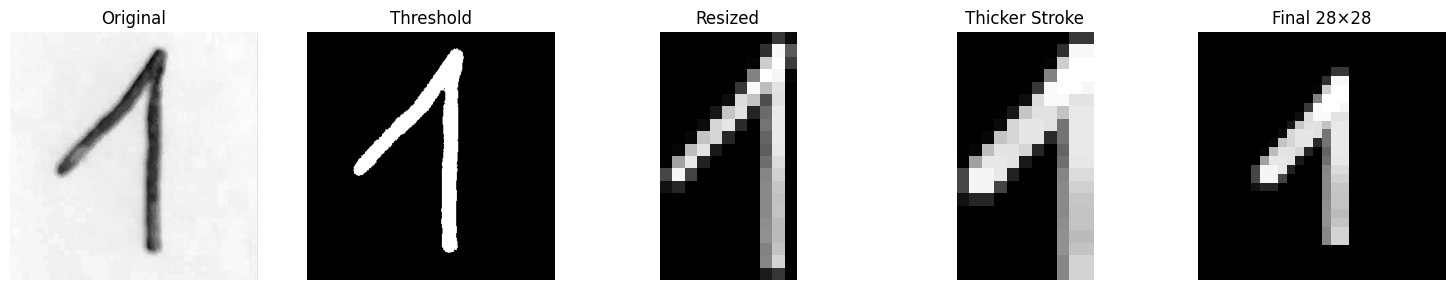

In [30]:
image_path = "../test_images/1.png"

processed = preprocess_digit(image_path)

In [31]:
prediction = model.predict(processed, verbose=0)

digit = np.argmax(prediction[0])
confidence = prediction[0][digit] * 100

print("Predicted digit:", digit)
print(f"Confidence: {confidence:.2f}%")

Predicted digit: 1
Confidence: 99.29%


In [32]:
for i, probability in enumerate(prediction[0]):
    print(f"{i}: {probability * 100:.2f}%")

0: 0.00%
1: 99.29%
2: 0.00%
3: 0.00%
4: 0.70%
5: 0.00%
6: 0.00%
7: 0.01%
8: 0.00%
9: 0.00%
